# CBIS-DDSM Breast Cancer EDA

Adapted from the original Kaggle notebook (awsaf49/breast-cancer-eda) to run locally
against a downloaded copy of the dataset, plus pathology-label EDA needed for framing
this as an anomaly detection problem (normal vs. malignant) rather than a straight
classification task.

In [1]:
# One-time environment setup (run once, then comment out)
# python3 -m venv .venv && source .venv/bin/activate
# pip install -r ../requirements.txt

## 1. Dataset

In [2]:
import sys
sys.path.insert(0, '..')  # repo root, so `src` is importable from here

from src.data.cbis_ddsm import resolve_dataset_dir

dataset_dir = resolve_dataset_dir()
dataset_dir

'/Users/toriav/Desktop/Erem - Honours/mammo-uad-2d3d/data/archive'

## 2. Checking download

CSVs and image folders download check before running anything on the full dataset

In [3]:
import os

expected = ['csv', 'jpeg']  # top-level folders CBIS-DDSM ships with
found = os.listdir(dataset_dir)
print("Found:", found)
for e in expected:
    status = "OK" if e in found else "MISSING"
    print(f"  {e}: {status}")

Found: ['csv', 'jpeg']
  csv: OK
  jpeg: OK


## 3. Load pathology labels (benign vs. malignant)

The original EDA notebook only looks at `dicom_info.csv`, which has image metadata but
**no pathology labels**. For the anomaly detection framing (train on normal, flag
malignant at test time), we need `mass_case_description*.csv` and
`calc_case_description*.csv`, which carry the `pathology` column
(`BENIGN`, `BENIGN_WITHOUT_CALLBACK`, `MALIGNANT`).

In [4]:
import pandas as pd

csv_dir = f'{dataset_dir}/csv'
mass_train = pd.read_csv(f'{csv_dir}/mass_case_description_train_set.csv')
mass_test  = pd.read_csv(f'{csv_dir}/mass_case_description_test_set.csv')
calc_train = pd.read_csv(f'{csv_dir}/calc_case_description_train_set.csv')
calc_test  = pd.read_csv(f'{csv_dir}/calc_case_description_test_set.csv')

cases = pd.concat([
    mass_train.assign(abnormality='mass', split='train'),
    mass_test.assign(abnormality='mass', split='test'),
    calc_train.assign(abnormality='calcification', split='train'),
    calc_test.assign(abnormality='calcification', split='test'),
], ignore_index=True)

cases['pathology_binary'] = cases['pathology'].map(
    lambda p: 'MALIGNANT' if p == 'MALIGNANT' else 'BENIGN'
)
cases.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,abnormality,split,breast density,calc type,calc distribution,pathology_binary
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,mass,train,NaN,NaN,NaN,MALIGNANT
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,train,NaN,NaN,NaN,MALIGNANT
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,mass,train,NaN,NaN,NaN,BENIGN
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,train,NaN,NaN,NaN,BENIGN
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,mass,train,NaN,NaN,NaN,BENIGN


## 4. Class balance

 This decides the anomaly split. Benign/malignant counts, before deciding train/test structure. If malignant is a small minority (typical for this dataset), that supports training the anomaly model on benign-only and holding out malignant as the anomaly class at test time, matching how Dinomaly and AnomalyMoE are evaluated in their own papers.

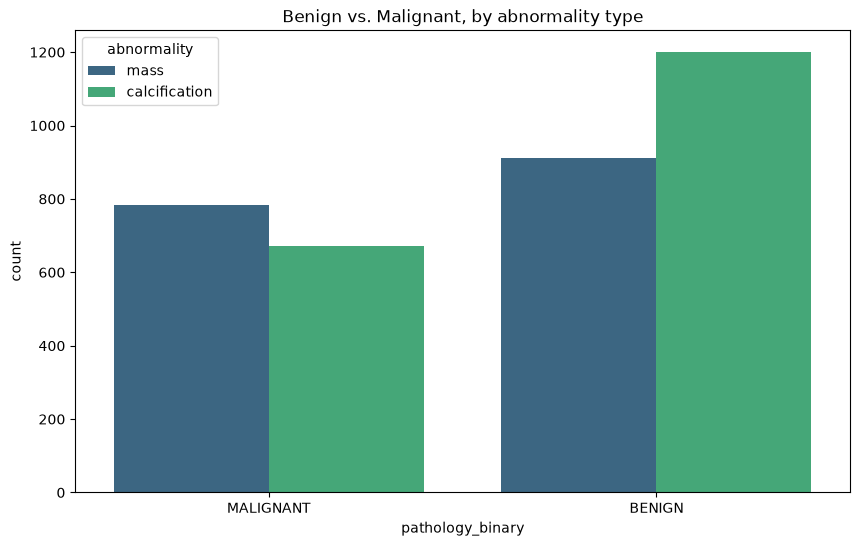

split  pathology_binary
test   BENIGN               428
       MALIGNANT            276
train  BENIGN              1683
       MALIGNANT           1181
dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=cases, x='pathology_binary', hue='abnormality', palette='viridis')
plt.title('Benign vs. Malignant, by abnormality type')
plt.show()

print(cases.groupby(['split', 'pathology_binary']).size())

Benign outnumbers malignant roughly 3:2 at the abnormality-row level (2111 vs 1457), and calcification cases skew benign harder than mass cases do. Malignant is a large minority, not a rare event, so the held-out anomaly set will be well populated. After collapsing to one row per full mammogram and taking the patient-level split, the loader reports 1580 normal / 1277 anomaly images, so the class split at image level is closer to 55/45.

## 5. Image-level EDA

Adapted  from the original DICOM-metadata / image-grid EDA notebook, repointed at the local dataset.

In [6]:
import pandas as pd, numpy as np
import os, shutil
from glob import glob
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from colorama import Fore, Back, Style
sns.set(style='dark')

In [7]:
df = pd.read_csv(f'{dataset_dir}/csv/dicom_info.csv')
df['image_path'] = df.image_path.apply(lambda x: x.replace('CBIS-DDSM', dataset_dir))
df.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,/Users/toriav/Desktop/Erem - Honours/mammo-uad...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,/Users/toriav/Desktop/Erem - Honours/mammo-uad...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,/Users/toriav/Desktop/Erem - Honours/mammo-uad...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,/Users/toriav/Desktop/Erem - Honours/mammo-uad...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,/Users/toriav/Desktop/Erem - Honours/mammo-uad...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [8]:
def show_img(path):
    img = cv2.imread(path,0)
    plt.figure(figsize=(10,10))
    plt.imshow(img,cmap='bone')

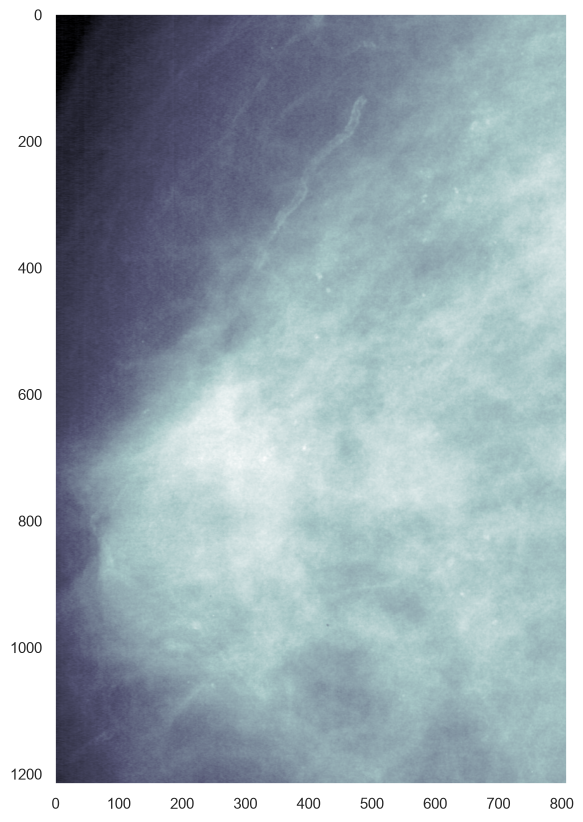

In [9]:
show_img(df.image_path.iloc[10])

Single JPEG read straight from disk, plotted with `cmap='bone'`. 8-bit grayscale, so the DICOM 12/16-bit dynamic range is already gone in this Kaggle mirror. Nothing to do about that here, but it's worth remembering when comparing against papers that work off raw DICOM.

# Image Size Extraction
same as `df.Rows` or `df.Columns`

In [10]:
%%time
import imagesize
data = df['image_path'].map(lambda path: imagesize.get(path))
width, height = list(zip(*data))
df['width'] = width
df['height'] = height
# df.head()

CPU times: user 2.6 s, sys: 639 ms, total: 3.24 s
Wall time: 3.24 s


# Width and Height Distribution

/var/folders/dy/drthcs692hg8sdl9fn1dp1700000gr/T/ipykernel_8767/354393909.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['width'], shade=True, color='limegreen')
/var/folders/dy/drthcs692hg8sdl9fn1dp1700000gr/T/ipykernel_8767/354393909.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['height'], shade=True, color='gold')


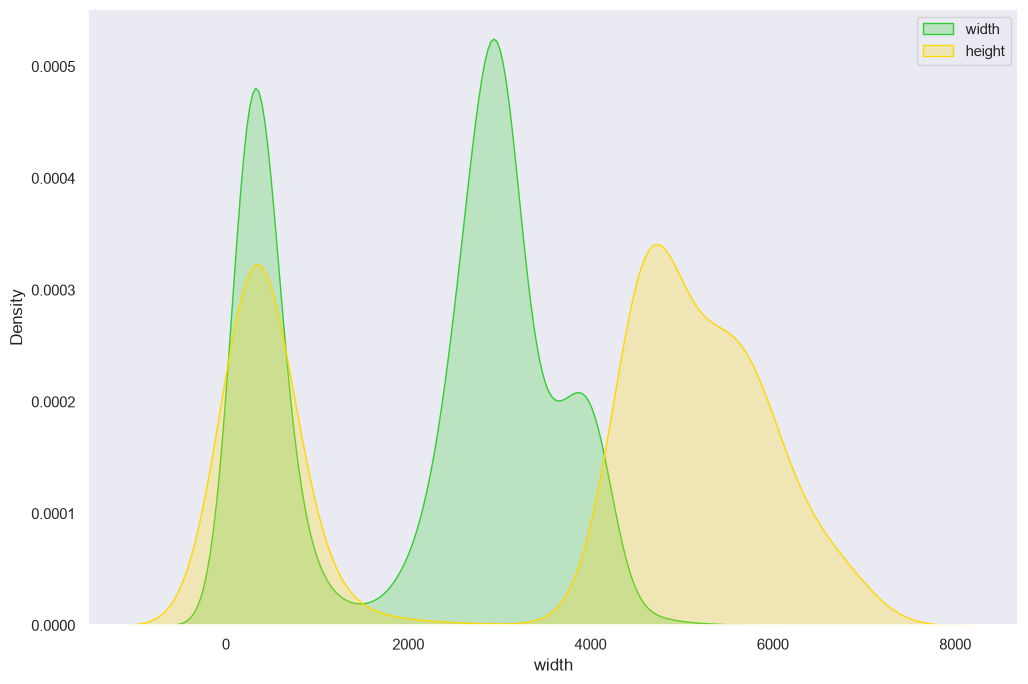

In [11]:
plt.figure(figsize=(12,8))
sns.kdeplot(df['width'], shade=True, color='limegreen')
sns.kdeplot(df['height'], shade=True, color='gold')
plt.legend(['width','height'])

Two populations. The narrow spike under ~1000 px on both axes is the cropped patches; the broad hump at ~3000 px wide / ~5000 px tall is the full mammograms. Full mammogram median is 3016 x 5236. Resizing that to 448 on the long side is about a 12x downscale, which will wash out individual microcalcifications. Masses should survive it.

# Aspect Ratio

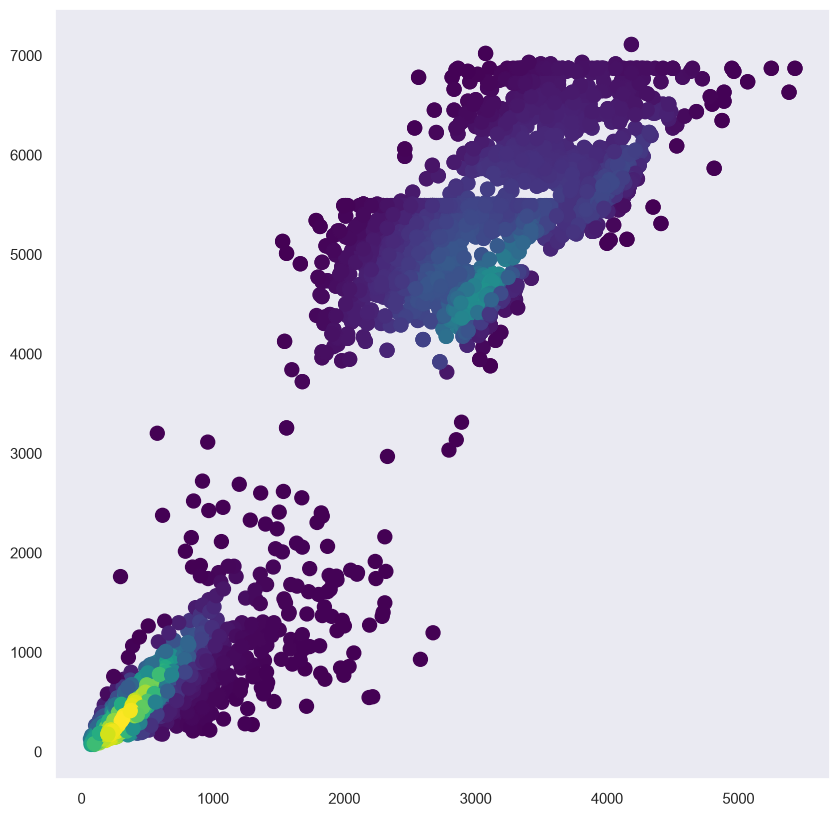

In [12]:
from scipy.stats import gaussian_kde


x_val = df.width.values
y_val = df.height.values

# Calculate the point density
xy = np.vstack([x_val,y_val])
z = gaussian_kde(xy)(xy)

fig, ax = plt.subplots(figsize = (10, 10))
# ax.axis('off')
ax.scatter(x_val, y_val, c=z, s=100, cmap='viridis')
# ax.set_xlabel('x_mid')
# ax.set_ylabel('y_mid')
plt.show()

Same two clusters in 2D. The full mammograms sit in a tight band with median aspect ratio 1.66 (portrait), so a square resize stretches them horizontally by the same factor every time. Consistent distortion is easier for a model to absorb than random distortion, but an aspect-preserving pad is an option to revisit if results are weak.

# One Row

In [13]:
for info in zip(df.iloc[0].index, df.iloc[0]):
    print(f'{Fore.GREEN}{info[0]}{Style.RESET_ALL}:',info[1])

file_path: CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.dcm
image_path: /Users/toriav/Desktop/Erem - Honours/mammo-uad-2d3d/data/archive/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg
AccessionNumber: nan
BitsAllocated: 16
BitsStored: 16
BodyPartExamined: BREAST
Columns: 351
ContentDate: 20160426
ContentTime: 131732.685
ConversionType: WSD
HighBit: 15
InstanceNumber: 1
LargestImagePixelValue: 65535
Laterality: R
Modality: MG
PatientBirthDate: nan
PatientID: Mass-Training_P_01265_RIGHT_MLO_1
PatientName: Mass-Training_P_01265_RIGHT_MLO_1
PatientOrientation: MLO
PatientSex: nan
PhotometricInterpretation: MONOCHROME2
PixelRepresentation: 0
ReferringPhysicianName: nan
Rows: 289
SOPClassUID: 1.2.840.10008.5.1.4.1.1.7
SOPInstanceUID: 1.3.6.1.4.1.9590.100.1.2.426380754911844882201419900442081103076
SamplesPerPixel: 1
SecondaryCaptureDeviceManufacturer: MathWorks
SecondaryCaptureDeviceManufacturerModelName: MATLAB
Serie

# Types of Images

Text(0.5, 1.0, 'Image count by SeriesDescription')

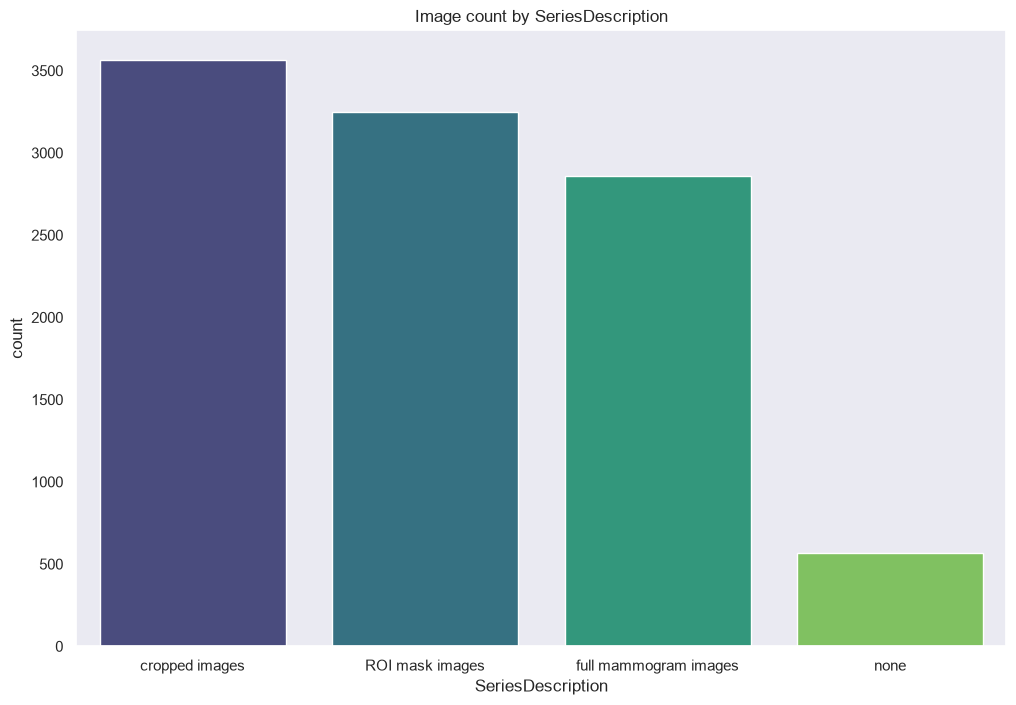

In [14]:
counts = df.SeriesDescription.fillna('none').value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False)
plt.ylabel('count')
plt.title('Image count by SeriesDescription')

cropped 3567, ROI mask 3247, full mammogram 2857, and 566 with no SeriesDescription. The loader uses full mammograms only, matched through `dicom_info.csv`, so the crops and masks here are not fed to the model.

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
import random

def show_grid(files, row=3, col=3):
    grid_files = random.sample(files, row*col)
    images     = []
    for image_path in tqdm(grid_files):
        img          = cv2.resize(cv2.imread(image_path), dsize=(512,512))
        images.append(img)

    fig = plt.figure(figsize=(col*5, row*5))
    grid = ImageGrid(fig, 111,  # similar to subplot(111)
                     nrows_ncols=(col, row),  # creates 2x2 grid of axes
                     axes_pad=0.05,  # pad between axes in inch.
                     )

    for ax, im in zip(grid, images):
        # Iterating over the grid returns the Axes.
        ax.imshow(im)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

# Cropped

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 492.04it/s]

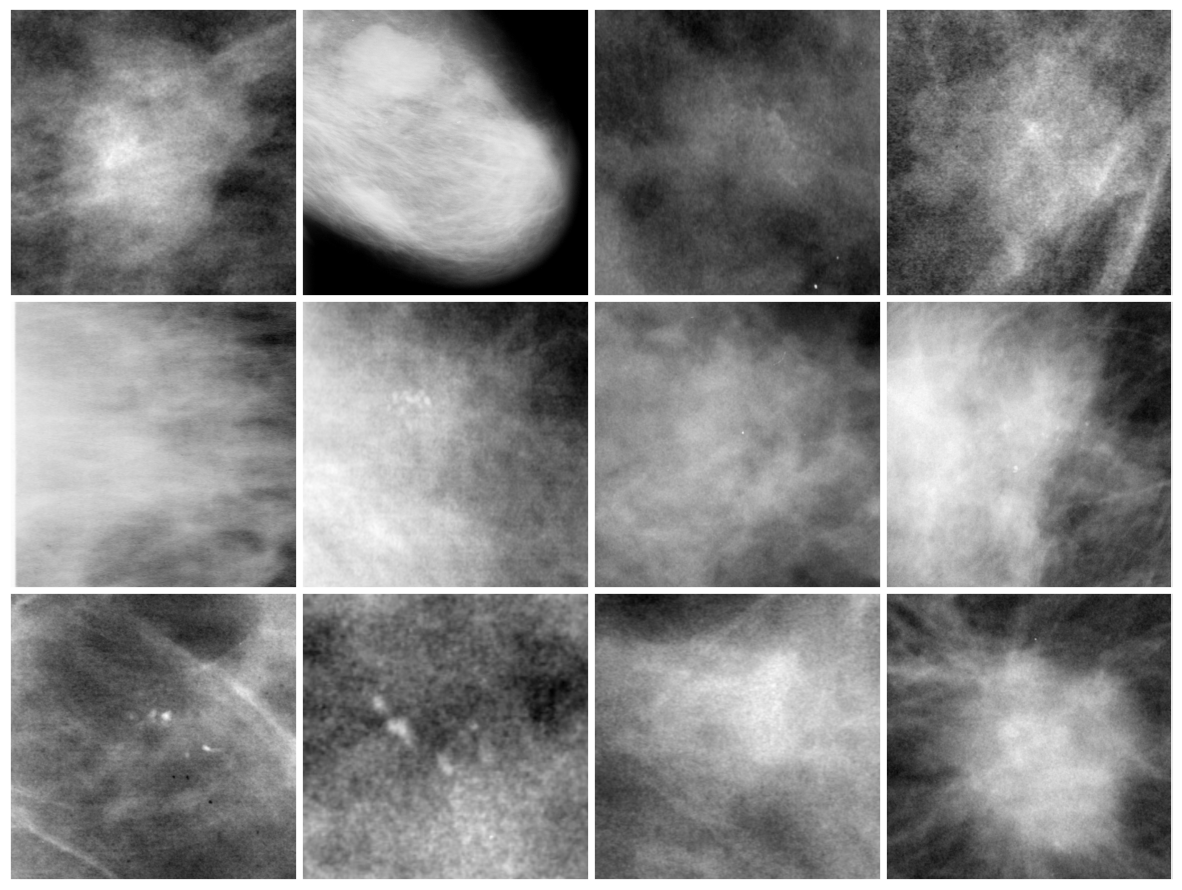

In [16]:
show_grid(df[df.SeriesDescription=='cropped images'].image_path.tolist(), row=4)

Tight ROI crops around the finding. Scale and contrast vary a lot between cases. Not used for the anomaly model (that runs on whole images), but useful later for sanity-checking what the ROI masks actually point at.

# Full Mammogram

  0%|          | 0/12 [00:00<?, ?it/s]

 42%|████▏     | 5/12 [00:00<00:00, 46.79it/s]

 92%|█████████▏| 11/12 [00:00<00:00, 50.40it/s]

100%|██████████| 12/12 [00:00<00:00, 49.58it/s]

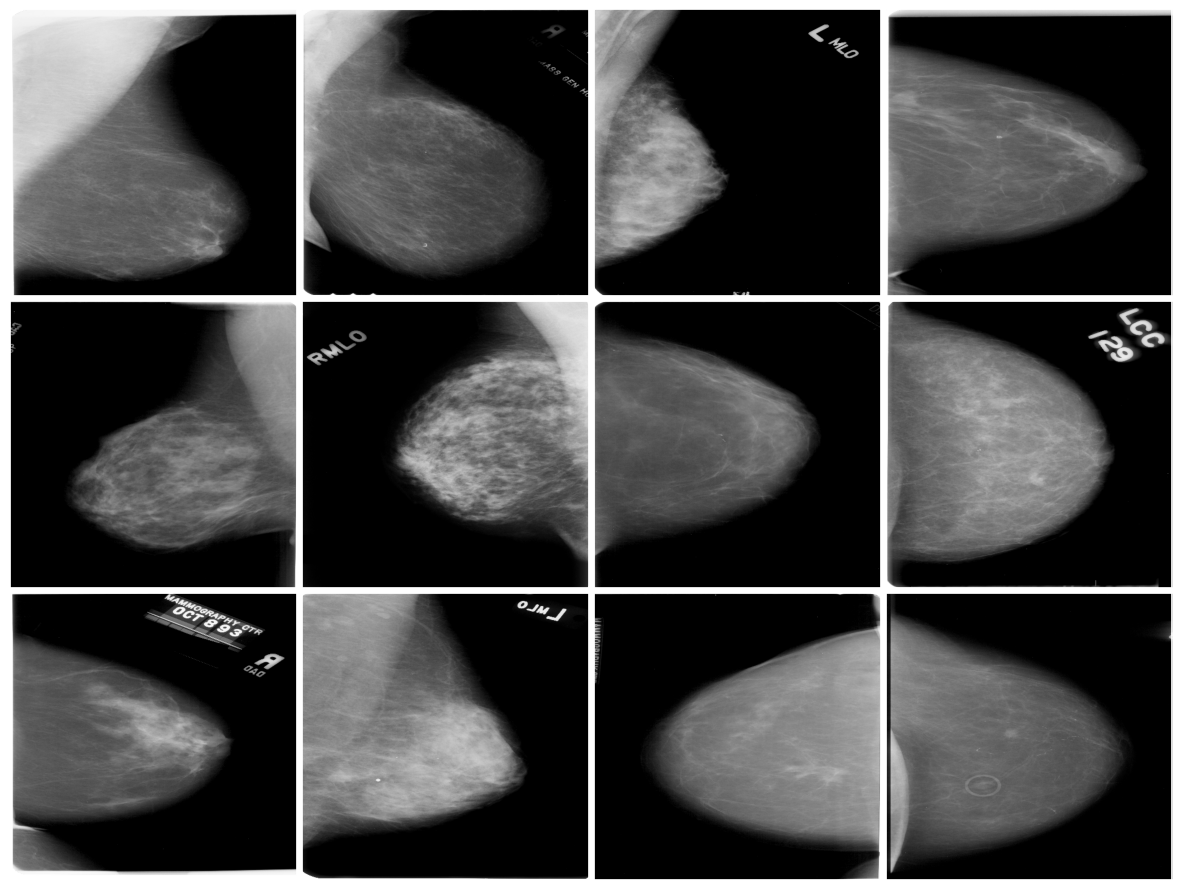

In [17]:
show_grid(df[df.SeriesDescription=='full mammogram images'].image_path.tolist(), row=4)

This is what the model sees. Whole breast, one view (CC or MLO), large black background, breast off to one side, view label burned into a corner. The breast occupies roughly half the frame, so a plain square resize spends a lot of pixels on background. A breast-region crop before resize is the obvious first improvement if the baseline underperforms.

# ROI mask

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 142.74it/s]

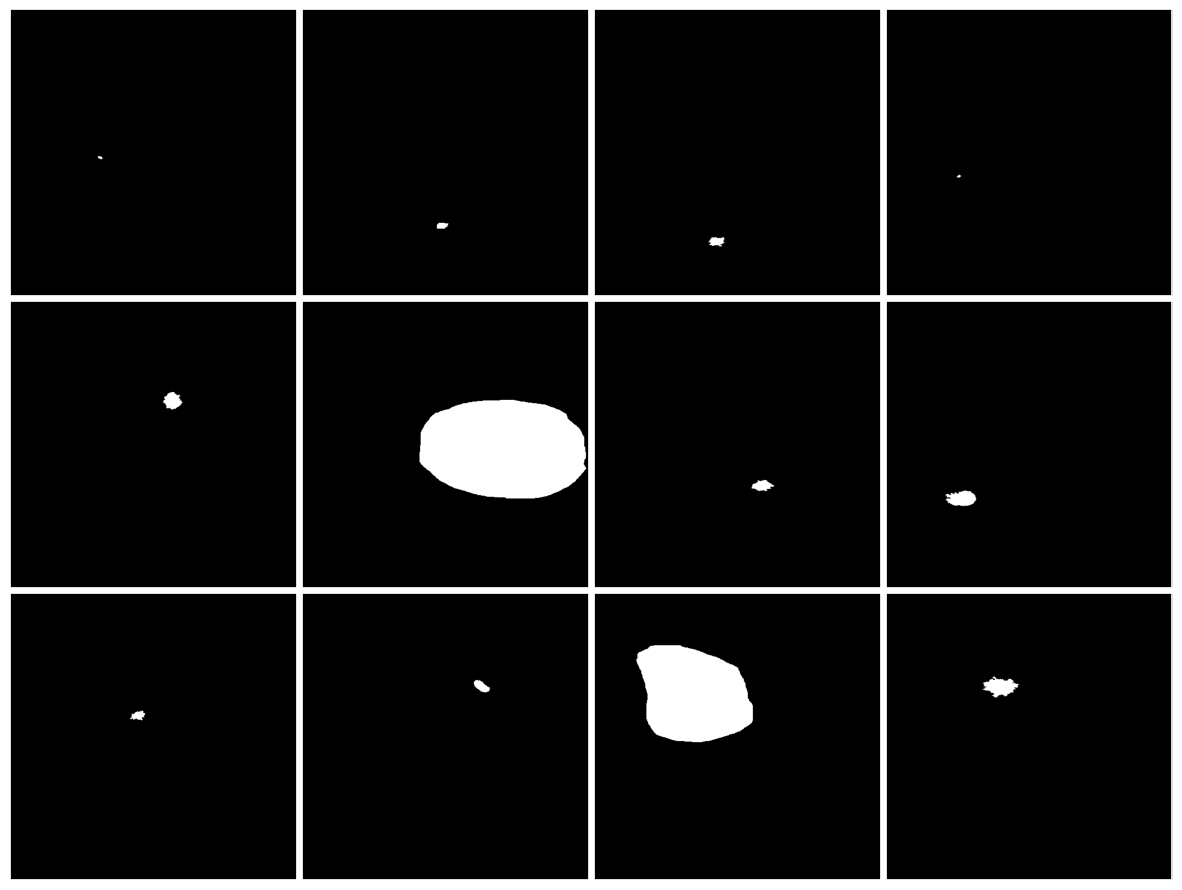

In [18]:
show_grid(df[df.SeriesDescription=='ROI mask images'].image_path.tolist(), row=4)

Binary masks marking the abnormality. Most are small relative to the full frame, which confirms the anomaly signal is local. Only malignant cases have masks that matter for the anomaly framing; no masks exist for normal breasts, so evaluation here is image-level rather than pixel-level.

# None

  0%|          | 0/12 [00:00<?, ?it/s]

 75%|███████▌  | 9/12 [00:00<00:00, 87.69it/s]

100%|██████████| 12/12 [00:00<00:00, 97.96it/s]

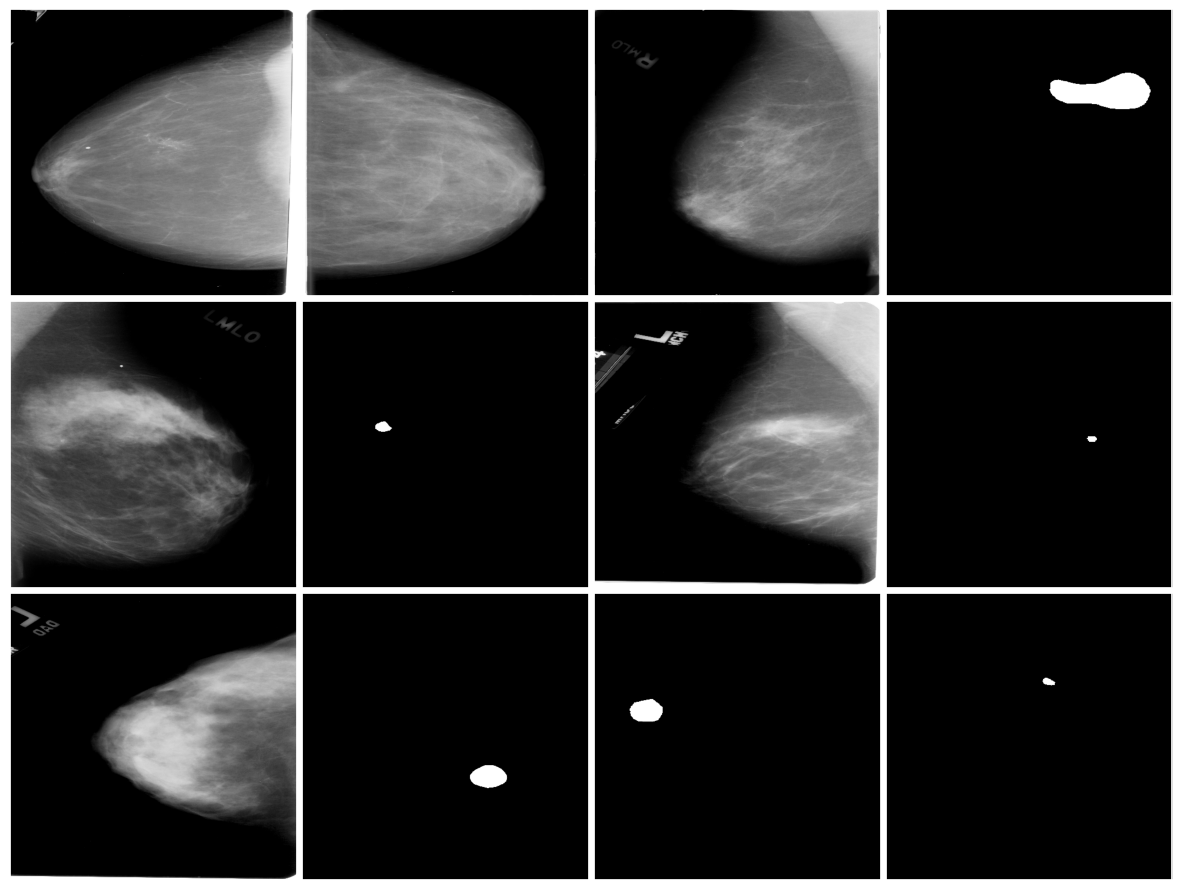

In [19]:
show_grid(df[df.SeriesDescription.isna()].image_path.tolist(), row=4)

The 566 rows with no SeriesDescription are a mix of full mammograms, masks, and crops. Filtering on `SeriesDescription == 'full mammogram images'` drops them, which is why the loader logs ~282 abnormality rows it can't resolve to a full mammogram.

## 6. Data loader check

Builds the train/test splits from `src/data/cbis_ddsm.py` and checks split sizes and batch shape. Image size, batch size, and split ratio below match Dinomaly's own MVTec config (448 resize / 392 crop, batch 16) and a patient-level 85/15 normal train/test split, with all malignant images held out of training.

In [20]:
from src.data.cbis_ddsm import load_datasets
from torch.utils.data import DataLoader

datasets = load_datasets()
for name, ds in datasets.items():
    print(f'{name}: {len(ds)} images')

train_loader = DataLoader(datasets['train_normal'], batch_size=16, shuffle=True)
imgs, labels = next(iter(train_loader))
print('batch shape:', imgs.shape)
print('batch labels:', labels[:4])

build_image_index: dropping 282 abnormality rows with no matching full-mammogram entry in dicom_info.csv
train_normal: 1353 images
test_normal: 227 images
test_anomaly: 1277 images


batch shape: torch.Size([16, 3, 392, 392])
batch labels: ('normal', 'normal', 'normal', 'normal')


## 7. Next steps

- Confirm with Rayhan: benign-vs-malignant split, or normal-vs-any-finding split.
- Data loader lives in `src/data/cbis_ddsm.py` now, built off the logic in this notebook (patient-level 85/15 normal train/test, malignant held out entirely). See the check above for split sizes and batch shape.
- Next: port the Dinomaly architecture (`third_party/Dinomaly`) onto this data loader.